# Genetic Variance

In this section, we will validate the simulation results of underdominance + effect size simulation by comparing it against the theoretical genetic variance.

The underdominance simulation under the Wright-Fisher setting was conducted by using the following parameters:
- N (Population size): 1000
- w2 (Selection strength): 1
- Sequence length: 1e8
- Mutation rate: We set the mutation rate (per site per individual per generation) as U / (sequence length), where U is the mutation rate per individual per generation
- Selection coefficient distribution: Gamma(shape = 1, scale = 10)/N - Used the default parameters that are used in Simons et al. (2018)
- Recombination rate: 1e-8

In [1]:
from scipy import special
from scipy import integrate
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tskit
import tstrait

import statsmodels.api as sm

In [2]:
# We will define the distribution of the sojourn time, which is
# defined as \tau(q|S) in the paper (Page 6, Eq. A18).

def ndtr_erf(z0,z1):
    return 2*(np.exp(special.log_ndtr(z1*np.sqrt(2)))-np.exp(special.log_ndtr(z0*np.sqrt(2))))

def f_plus(x, y):
    answer = special.erf(np.sqrt(x)/2)+special.erf(np.sqrt(x)*(1-2*y)/2)
    return answer

def f_minus(x,y):
    answer = special.erf(np.sqrt(x)/2)-special.erf(np.sqrt(x)*(1-2*y)/2)
    return answer

def tau(q, N, S):
    """
    q is the allele frequency, N is the population size, and S is
    the scaled selection coefficient
    """
    first = N*np.sqrt(np.pi/S)/special.erf(np.sqrt(S)/2)
    second = np.exp(S*(1-2*q)**2/4)/(q*(1-q))
    const = first * second
    
    if 0 <= q <= 1/(2*N):
        answer = const * f_minus(S, q) * f_plus(S, 1/(2*N))
    elif 1/(2*N) <= q <= 1:
        answer = const * f_plus(S, q) * f_minus(S, 1/(2*N))

    return answer

In [3]:
# We will define E[V|S] in Equation A25, which expresses the expected
# genetic variance per site
# v = 2a^2q(1-q) and q\in [0,1]
def integrand(q, N, S):
    function = 1/2*S*q*(1-q)*tau(q, N, S)
    return function

def E_VS(S, N, w=1, n=1):
    """
    This determines the expectation of V = 2a^2*q(1-q), which is the genetic variance per site
    w is the constant that influences the trait distribution and the default is 1.
    n is the degree of pleiotropy, and the default is 1.
    """
    integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]
    answer = 2*w**2/(n*N)*integral
    return answer

In [4]:
E_VS(S=1000, N=1000)

0.0

To validate the `E_VS` function, we will be replicating Figure 2A of the paper to illustrate how scaled selection coefficient influences expected variance.

In [5]:
# v_s is the expected contribution at sites under strong selection, which is defined as the following:
def vs(N, w=1, n=1):
    """
    This determines the expected contribution to genetic variance per site under strong selection.
    N is the population size
    w is the constant that influences the trait distribution and the default is 1.
    n is the degree of pleiotropy, and the default is 1.
    """
    return 2*w**2/(n*N)    

In [6]:
# The paper uses N=1000 to produce Figure 2A, so we will be using it as well
num = 50
S = np.logspace(-3,3, num=num)
exp_var = np.zeros(num)

for i in range(num):
    exp_var[i] = E_VS(S=S[i], N=1000)

exp_var /= vs(N=1000)

C:\Users\daiki\AppData\Local\Temp\ipykernel_14808\1003841213.py:14: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]
C:\Users\daiki\AppData\Local\Temp\ipykernel_14808\1003841213.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]


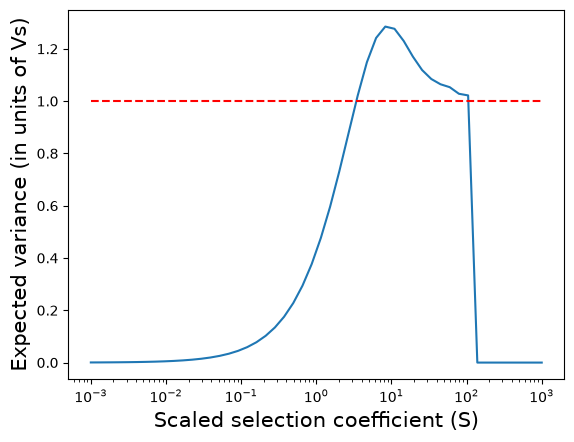

In [7]:
plt.plot(S, exp_var)
plt.xscale("log")
plt.hlines(y=1, xmin=np.min(S), xmax=np.max(S), linestyle="dashed", color="r")
plt.xlabel("Scaled selection coefficient (S)", fontsize=15)
plt.ylabel("Expected variance (in units of Vs)", fontsize=15)
plt.show()

We see that the function performs well until around `S=100`, but the function becomes 0 afterwards, instead of being 1 as expected. This is due to the fact that `scipy.special.erf()` function returns `1` when the value is big, so it is difficult to compute the differences between two erfs as shown in the below code:

In [8]:
special.erf(2000) - special.erf(1000)

np.float64(0.0)

In [9]:
special.erf(1000)

np.float64(1.0)

It would be possible for Mathematica to resolve this issue, but for our purpose, we will simply modify the `E_VS` function, such that the value will be `Vs` when `S` is larger than `100` (Or otherwise, it would be difficult to compute the integral of it, which we will do it afterwards).

In [10]:
def E_VS_scaled(S, N, w=1, n=1):
    """
    This determines the expectation of genetic variance per site.
    Since E_VS becomes 0 when S is large due to the rounding errors of scipy.special.erf function,
    we will make the function return  when S is large.
    """
    if S <= 100:
        answer = E_VS(S=S, N=N, w=w, n=n)
    else:
        answer = vs(N=N, w=w, n=n)

    return answer

In [11]:
# The paper uses N=1000 to produce Figure 2A, so we will be using it as well
num = 50
S = np.logspace(-3,3, num=num)
exp_var = np.zeros(num)

for i in range(num):
    exp_var[i] = E_VS_scaled(S=S[i], N=1000)

exp_var /= vs(N=1000)

C:\Users\daiki\AppData\Local\Temp\ipykernel_14808\1003841213.py:14: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]


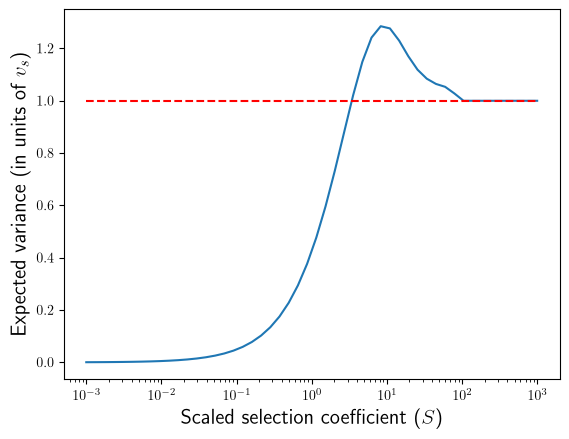

In [13]:
plt.rcParams['text.usetex'] = True
plt.plot(S, exp_var)
plt.xscale("log")
plt.hlines(y=1, xmin=np.min(S), xmax=np.max(S), linestyle="dashed", color="r")
plt.xlabel("Scaled selection coefficient ($S$)", fontsize=15)
plt.ylabel(r"Expected variance (in units of $v_s$)", fontsize=15)
plt.savefig("expected-variance-numerical-integration.pdf")
plt.show()

The above figure looks like Figure 2A in the paper. We will next compute the total additive genetic variance over all sites.

In [13]:
# We will now obtain the total additive genetic variance over all sites
# which is expressed in Equation A25 of Supplementary material page 8.
def sigma(N, U, scale, shape, w=1, n=1):
    """
    This determines the total additive genetic variance over all sites.
    We assume that the scaled selection coefficient is taken from the Ga
    
    N is the population size
    U is the mutation rate per individual per generation
    scale is the scale parameter of the Gamma distribution
    shape is the shape parameter of the Gamma distribution
    w is the constant that influences the trait distribution and the default is 1.
    n is the degree of pleiotropy, and the default is 1.
    """
    # In scipy.stats.gamma.pdf, a is the shape parameter of the distribution
    # S is the scaled selection coefficient, which ranges from (0, infty)
    integral = integrate.quad(lambda S: E_VS_scaled(S, N=N, w=w, n=n)*stats.gamma.pdf(S, a=shape, scale=scale*N), 0, np.inf)[0]
    sigma2 = 2*N*U*integral

    return sigma2

In [14]:
sigma(N=24744, U=0.01, shape=1, scale=1)

0.04001011315685127

We will now use the above `sigma` function to produce the theoretical results that is included in Figure A6.

In [15]:
# The paper uses N=1000 and shape=1 to produce Figure A6.
num = 20
U = np.logspace(-3, -1, num=num)
sigma_plot = np.zeros(num)

scale = 10

for i in range(num):
    sigma_plot[i] = sigma(N=1000, U=U[i], scale=10, shape=1)

C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]
C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]


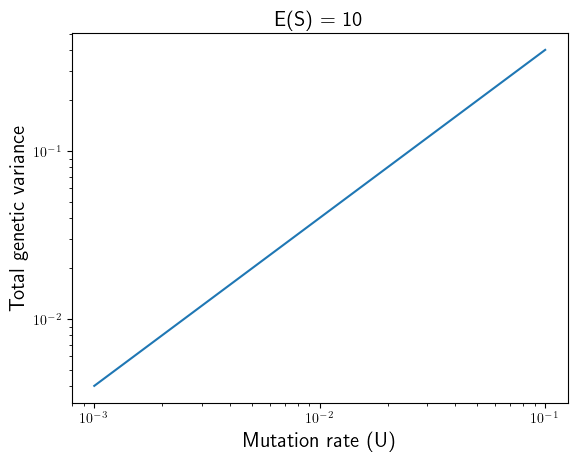

In [16]:
plt.loglog(U, sigma_plot)
plt.xlabel("Mutation rate (U)", fontsize=15)
plt.ylabel("Total genetic variance", fontsize=15)
plt.title("E(S) = 10", fontsize=15)
plt.show()

This aligns perfectly with Figure A6 in Supplementary material page 15, so we will compare it against the SLiM results.

In [64]:
# n = 100
num = 20
U = np.logspace(-2, 0, num=num)
sigma_plot_n100_S10 = np.zeros(num)

for i in range(num):
    sigma_plot_n100_S10[i] = sigma(N=1000, U=U[i], scale=10, shape=1, n=100)

C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]
C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]


In [65]:
# n = 100
num = 20
U = np.logspace(-2, 0, num=num)
sigma_plot_n100_S50 = np.zeros(num)

for i in range(num):
    sigma_plot_n100_S50[i] = sigma(N=1000, U=U[i], scale=50, shape=1, n=100)

C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]
C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]


In [66]:
# n = 10
num = 20
U = np.logspace(-2, 0, num=num)
sigma_plot_n10_S10 = np.zeros(num)

for i in range(num):
    sigma_plot_n10_S10[i] = sigma(N=1000, U=U[i], scale=10, shape=1, n=10)

C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]
C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]


In [67]:
# n = 10
num = 20
U = np.logspace(-2, 0, num=num)
sigma_plot_n10_S50 = np.zeros(num)

for i in range(num):
    sigma_plot_n10_S50[i] = sigma(N=1000, U=U[i], scale=50, shape=1, n=10)

C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]
C:\Users\daiki\AppData\Local\Temp\ipykernel_28048\1003841213.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = integrate.quad(integrand, 0, 1, args=(N, S))[0]


## tstrait simulation

In [20]:
def obtain_mutation_df(ts):
    variant = tskit.Variant(ts)
    # All mutations are happening at the same time, so we can obtain the node for the 1st
    # mutation
    # Time is in forward simulation
    mutation_list = []
    for i in range(ts.num_mutations):
        mutation = ts.mutation(i)
        variant.decode(mutation.site)
        alleles = np.array(variant.alleles)
        genotype = alleles[variant.genotypes]
        allele_freq = np.count_nonzero(genotype == mutation.derived_state)/len(variant.genotypes)
            
        mutation_list.append(
            {
                "site_id": mutation.site,
                "selection_coeff": mutation.metadata["mutation_list"][0]["selection_coeff"],
                "causal_allele": mutation.derived_state,
                "trait_id": 0,
                "allele_freq": allele_freq,
            }
        )
    
    mutation_df = pd.DataFrame(mutation_list)
    mutation_df["selection_coeff"] = mutation_df["selection_coeff"]*1e10*(-2)

    return mutation_df

In [21]:
def simulate_effect(selection_coeff, n, rng, w2=1):
    effect_size = rng.normal(loc = 0, scale = np.sqrt(w2/n*selection_coeff))
    return effect_size

In [22]:
def sim_tstrait_pleiotropy(mutation_df, n, w2=1, seed=None):
    rng = np.random.default_rng(seed=seed)
    mutation_df["effect_size"] = mutation_df.apply(lambda row: simulate_effect(row["selection_coeff"], w2=w2, n=n, rng=rng), axis=1)
    genetic_df = tstrait.genetic_value(ts, mutation_df)
    return genetic_df

In [23]:
def sim_genetic_var(ts, n, w2=1, seed=None):
    mutation_df = obtain_mutation_df(ts)
    genetic_df = sim_tstrait_pleiotropy(mutation_df, n=n, seed=seed)
    return np.var(genetic_df.genetic_value)

In [41]:
def ts_list_S10():
    file_list = [
        "underdominance_popsize_1000_U_1_S_10_seed_25.tree",
        "underdominance_popsize_1000_U_0.3_S_10_seed_24.tree",
        "underdominance_popsize_1000_U_0.1_S_10_seed_23.tree",
        "underdominance_popsize_1000_U_0.03_S_10_seed_22.tree",
        "underdominance_popsize_1000_U_0.01_S_10_seed_21.tree",
]
    for file in file_list:
        yield tskit.load(file)

In [42]:
def ts_list_S50():
    file_list = [
        "underdominance_popsize_1000_U_1_S_50_seed_35.tree",
        "underdominance_popsize_1000_U_0.3_S_50_seed_34.tree",
        "underdominance_popsize_1000_U_0.1_S_50_seed_33.tree",
        "underdominance_popsize_1000_U_0.03_S_50_seed_32.tree",
        "underdominance_popsize_1000_U_0.01_S_50_seed_31.tree",
]
    for file in file_list:
        yield tskit.load(file)

In [68]:
result_S10_n100 = []
seed = 12456

for ts in ts_list_S10():
    result_S10_n100.append(sim_genetic_var(ts, n=100, seed=seed))
    seed += 1

In [70]:
result_S10_n10 = []
seed = 124567

for ts in ts_list_S10():
    result_S10_n10.append(sim_genetic_var(ts, n=10, seed=seed))
    seed += 1

In [71]:
result_S50_n100 = []
seed = 2222

for ts in ts_list_S50():
    result_S50_n100.append(sim_genetic_var(ts, n=100, seed=seed))
    seed += 1

In [73]:
result_S50_n10 = []
seed = 22

for ts in ts_list_S50():
    result_S50_n10.append(sim_genetic_var(ts, n=10, seed=seed))
    seed += 1

In [45]:
U_array = [1, 0.3, 0.1, 0.03, 0.01]

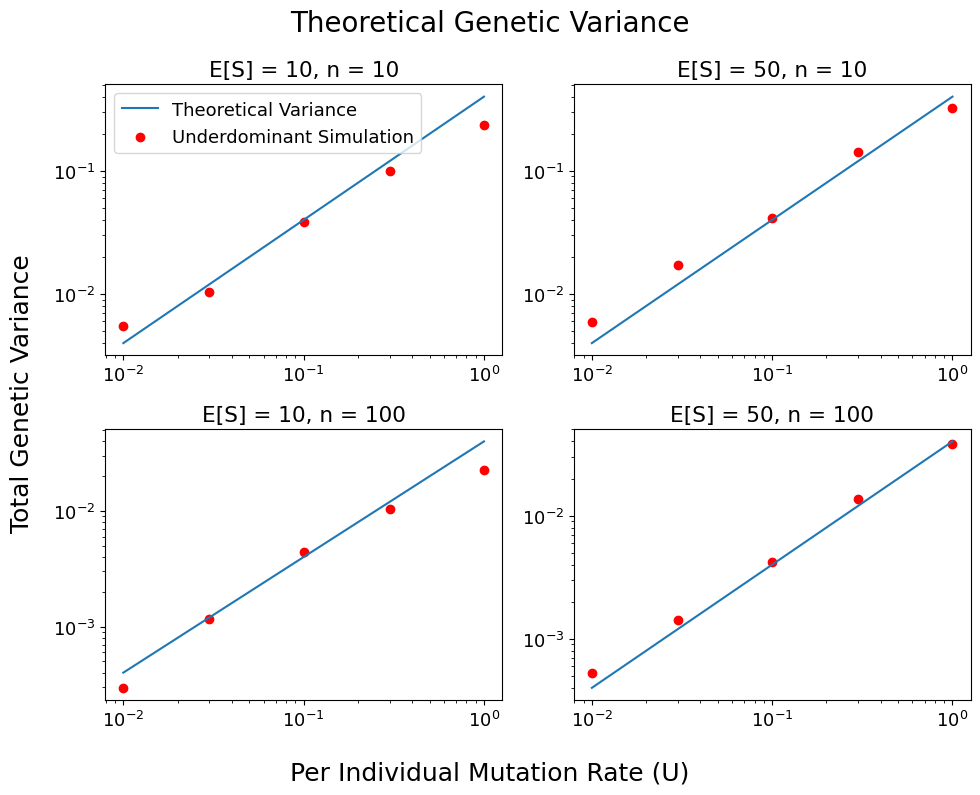

In [79]:
plt.rcParams['text.usetex'] = False
plt.rcParams.update({'font.size': 13})
fig, axs = plt.subplots(2, 2, tight_layout=True, figsize=(10, 8))

axs[0,0].loglog(U, sigma_plot_n10_S10, label="Theoretical Variance")
axs[0,0].scatter(U_array, result_S10_n10, color="r", label="Underdominant Simulation")
axs[0,0].set_title("E[S] = 10, n = 10")
axs[0,0].legend()

axs[0,1].loglog(U, sigma_plot_n10_S50, label="Theoretical Variance")
axs[0,1].scatter(U_array, result_S50_n10, color="r", label="Underdominant Simulation")
axs[0,1].set_title("E[S] = 50, n = 10")
#axs[0,1].legend()

axs[1,0].loglog(U, sigma_plot_n100_S10, label="Theoretical Variance")
axs[1,0].scatter(U_array, result_S10_n100, color="r", label="Underdominant Simulation")
axs[1,0].set_title("E[S] = 10, n = 100")
#axs[1,0].legend()

axs[1,1].loglog(U, sigma_plot_n100_S50, label="Theoretical Variance")
axs[1,1].scatter(U_array, result_S50_n100, color="r", label="Underdominant Simulation")
axs[1,1].set_title("E[S] = 50, n = 100")
#axs[1,1].legend()

fig.supxlabel("Per Individual Mutation Rate (U)", fontsize=18)
fig.supylabel("Total Genetic Variance", fontsize=18)
fig.suptitle("Theoretical Genetic Variance", fontsize=20)

plt.savefig("variance_theoretical_underdominant_simulation.pdf")

plt.show()